<a href="https://colab.research.google.com/github/tsjannoun123-netizen/AI-for-Med.Diagnos.-Prediction-AAI_643O_O11_202610/blob/main/Week6_Foundation__Model_Adaptation_Saera_Rawas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset sizes: Train=800, Val=200

FULL FINE-TUNING EXPERIMENT
Trainable parameters (Full FT): 765,697


Full FT Epoch 1: 100%|██████████| 50/50 [00:26<00:00,  1.90it/s]


Epoch 1: Loss: 0.4997, AUC: 1.0000, Time: 26.27s


Full FT Epoch 2: 100%|██████████| 50/50 [00:24<00:00,  2.00it/s]


Epoch 2: Loss: 0.2440, AUC: 1.0000, Time: 25.00s


...

Epoch 6: Loss: 0.0000, AUC: 1.0000, Time: 14.70s


Adapter Epoch 7: 100%|██████████| 50/50 [00:14<00:00,  3.40it/s]


Epoch 7: Loss: 0.0000, AUC: 1.0000, Time: 14.70s


Adapter Epoch 8: 100%|██████████| 50/50 [00:15<00:00,  3.33it/s]


Epoch 8: Loss: 0.0000, AUC: 1.0000, Time: 15.01s

RESULTS COMPARISON

FULL FINE-TUNING RESULTS:
Final AUC: 1.0000
Total Training Time: 232.67s
Average Epoch Time: 25.46s
Trainable Parameters: 765,697

ADAPTER-BASED TUNING RESULTS:
Final AUC: 1.0000
Total Training Time: 150.35s
Average Epoch Time: 15.06s
Trainable Parameters: 198,849

COMPARISON:
AUC Difference: 0.0000
Time Speedup: 1.55x
Parameter Efficiency: 3.85x


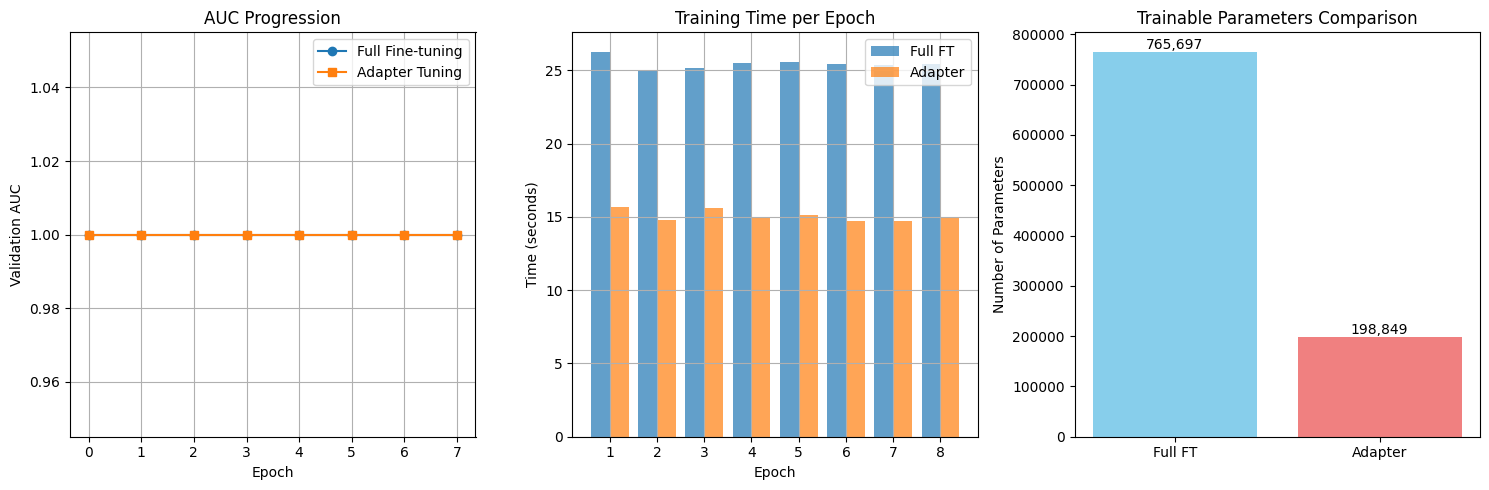


FINAL SUMMARY

Performance Comparison:
Metric               Full Fine-tuning   Adapter Tuning  Difference
------------------------------------------------------------
Final AUC            1.0000             1.0000          0.0000    
Total Time (s)       232.67             150.35          -82.32    
Avg Epoch Time (s)   25.46              15.06           -10.40    
Parameters           765,697            198,849         -566,848  

Key Insights:
• Adapter tuning is 1.55x faster than full fine-tuning
• Adapter tuning uses 26.0% of the parameters
• Performance difference: 0.0000 AUC points
✓ Adapter tuning achieves comparable performance with better efficiency


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.metrics import roc_auc_score
import time
import random
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================================
# 1. SIMULATED RADIOLOGY DATASET (Replace with actual dataset)
# ============================================================================

class RadiologyDataset(Dataset):
    def __init__(self, size=1000, image_size=224, train=True):
        self.size = size
        self.image_size = image_size
        self.train = train
        self.transform = transforms.Compose([
            transforms.ToPILImage(), # Add this line to convert tensor to PIL Image
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Simulate medical images (in practice, load real DICOM/PNG images)
        # Create synthetic images with different patterns
        if self.train:
            torch.manual_seed(idx)
        else:
            torch.manual_seed(idx + 10000)

        # Simulate different image patterns for pathology vs normal
        if idx % 2 == 0:  # Pathology cases
            # Create patterns that might resemble abnormalities
            base = torch.randn(3, self.image_size, self.image_size) * 0.1
            # Add some structured "abnormalities"
            y, x = torch.meshgrid(torch.linspace(-1, 1, self.image_size),
                                torch.linspace(-1, 1, self.image_size))
            mask = (x**2 + y**2) < 0.3
            base[:, mask] += torch.randn(1) * 0.5
            image = torch.clamp(base, 0, 1)
            label = 1
            text = "chest xray shows consolidation and opacity suggestive of pneumonia"
        else:  # Normal cases
            # More homogeneous pattern for normal cases
            image = torch.randn(3, self.image_size, self.image_size) * 0.05 + 0.5
            image = torch.clamp(image, 0, 1)
            label = 0
            text = "normal chest xray without acute cardiopulmonary process"

        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32), text

# ============================================================================
# 2. MEDCLIP MODEL IMPLEMENTATION (Simplified)
# ============================================================================

class MedCLIPModel(nn.Module):
    def __init__(self, hidden_size=512, projection_dim=256):
        super(MedCLIPModel, self).__init__()

        # Image encoder (simplified ResNet-50 backbone)
        self.vision_encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, hidden_size),
            nn.ReLU()
        )

        # Text encoder (simplified transformer)
        self.text_encoder = nn.Sequential(
            nn.Linear(384, hidden_size),  # Assuming 384-dim text embeddings
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        # Projection layers
        self.visual_projection = nn.Linear(hidden_size, projection_dim)
        self.text_projection = nn.Linear(hidden_size, projection_dim)

    def forward(self, images, text_embeddings):
        visual_features = self.vision_encoder(images)
        text_features = self.text_encoder(text_embeddings)

        visual_embeddings = self.visual_projection(visual_features)
        text_embeddings = self.text_projection(text_features)

        return visual_embeddings, text_embeddings

# ============================================================================
# 3. ADAPTER MODULES
# ============================================================================

class Adapter(nn.Module):
    def __init__(self, hidden_size, adapter_size, dropout=0.1):
        super(Adapter, self).__init__()
        self.down_project = nn.Linear(hidden_size, adapter_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.up_project = nn.Linear(adapter_size, hidden_size)

    def forward(self, x):
        residual = x
        x = self.down_project(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.up_project(x)
        return x + residual

class MedCLIPWithAdapters(nn.Module):
    def __init__(self, base_model, adapter_size=64):
        super(MedCLIPWithAdapters, self).__init__()
        self.base_model = base_model

        # Freeze base model parameters
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Add adapters to vision encoder
        self.vision_adapters = nn.ModuleList()
        for layer in self.base_model.vision_encoder:
            if isinstance(layer, nn.Linear):
                self.vision_adapters.append(Adapter(layer.out_features, adapter_size))
            else:
                self.vision_adapters.append(nn.Identity())

        # Add adapters to text encoder
        self.text_adapters = nn.ModuleList()
        for layer in self.base_model.text_encoder:
            if isinstance(layer, nn.Linear):
                self.text_adapters.append(Adapter(layer.out_features, adapter_size))
            else:
                self.text_adapters.append(nn.Identity())


        # Classification head
        self.classifier = nn.Linear(512, 1)  # Using vision features for classification

    def forward(self, images, text_embeddings):
        # Forward pass through vision encoder with adapters
        x = images
        for i, layer in enumerate(self.base_model.vision_encoder):
            x = layer(x)
            # Apply adapter only if the corresponding layer is a linear layer
            if isinstance(layer, nn.Linear):
                x = self.vision_adapters[i](x)
        visual_features = x


        # Forward pass through text encoder with adapters (not used for classification)
        y = text_embeddings
        for i, layer in enumerate(self.base_model.text_encoder):
            y = layer(y)
            # Apply adapter only if the corresponding layer is a linear layer
            if isinstance(layer, nn.Linear):
                y = self.text_adapters[i](y)
        text_features = y


        # Use visual features for pathology classification
        logits = self.classifier(visual_features)
        return torch.sigmoid(logits).squeeze()

# ============================================================================
# 4. TEXT EMBEDDING UTILITY
# ============================================================================

class TextEmbedder:
    def __init__(self, embedding_dim=384):
        self.embedding_dim = embedding_dim

    def embed_text(self, text_list):
        """Simulate text embeddings - in practice use actual CLIP text encoder"""
        embeddings = []
        for text in text_list:
            # Simple simulation: hash text to create deterministic "embeddings"
            seed = hash(text) % 10000
            torch.manual_seed(seed)
            embedding = torch.randn(self.embedding_dim)
            embeddings.append(embedding)
        return torch.stack(embeddings)

# ============================================================================
# 5. TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_full_finetuning(model, train_loader, val_loader, epochs=10, lr=1e-4):
    """Full fine-tuning of all parameters"""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()

    train_losses = []
    val_aucs = []
    train_times = []

    for epoch in range(epochs):
        model.train()
        epoch_start = time.time()
        running_loss = 0.0

        for images, labels, texts in tqdm(train_loader, desc=f'Full FT Epoch {epoch+1}'):
            text_embeddings = text_embedder.embed_text(texts)

            optimizer.zero_grad()
            outputs = model(images, text_embeddings)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_time = time.time() - epoch_start
        train_times.append(epoch_time)

        # Validation
        auc = evaluate_model(model, val_loader)
        val_aucs.append(auc)
        train_losses.append(running_loss / len(train_loader))

        print(f'Epoch {epoch+1}: Loss: {train_losses[-1]:.4f}, AUC: {auc:.4f}, Time: {epoch_time:.2f}s')

    return train_losses, val_aucs, train_times

def train_adapter_tuning(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """Adapter-based tuning - only train adapter parameters"""
    # Only optimize adapter and classifier parameters
    optimizer = optim.Adam([
        {'params': model.vision_adapters.parameters()},
        {'params': model.text_adapters.parameters()},
        {'params': model.classifier.parameters()}
    ], lr=lr, weight_decay=1e-4)

    criterion = nn.BCELoss()

    train_losses = []
    val_aucs = []
    train_times = []

    for epoch in range(epochs):
        model.train()
        epoch_start = time.time()
        running_loss = 0.0

        for images, labels, texts in tqdm(train_loader, desc=f'Adapter Epoch {epoch+1}'):
            text_embeddings = text_embedder.embed_text(texts)

            optimizer.zero_grad()
            outputs = model(images, text_embeddings)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_time = time.time() - epoch_start
        train_times.append(epoch_time)

        # Validation
        auc = evaluate_model(model, val_loader)
        val_aucs.append(auc)
        train_losses.append(running_loss / len(train_loader))

        print(f'Epoch {epoch+1}: Loss: {train_losses[-1]:.4f}, AUC: {auc:.4f}, Time: {epoch_time:.2f}s')

    return train_losses, val_aucs, train_times

def evaluate_model(model, data_loader):
    """Evaluate model and return AUC score"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels, texts in data_loader:
            text_embeddings = text_embedder.embed_text(texts)
            outputs = model(images, text_embeddings)
            all_predictions.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_predictions)
    return auc

def count_parameters(model):
    """Count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ============================================================================
# 6. EXPERIMENT SETUP AND EXECUTION
# ============================================================================

# Initialize components
text_embedder = TextEmbedder()

# Create datasets
train_dataset = RadiologyDataset(size=800, train=True)
val_dataset = RadiologyDataset(size=200, train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}")

# ============================================================================
# 7. FULL FINE-TUNING EXPERIMENT
# ============================================================================

print("\n" + "="*50)
print("FULL FINE-TUNING EXPERIMENT")
print("="*50)

# Create base model for full fine-tuning
base_model_ft = MedCLIPModel()
classification_head_ft = nn.Linear(512, 1)

class FullFineTunedModel(nn.Module):
    def __init__(self, base_model, classifier):
        super(FullFineTunedModel, self).__init__()
        self.base_model = base_model
        self.classifier = classifier

    def forward(self, images, text_embeddings):
        # Pass images through the full vision encoder
        visual_features = self.base_model.vision_encoder(images)
        # Pass text embeddings through the full text encoder (optional for classification)
        # text_features = self.base_model.text_encoder(text_embeddings) # Not needed for this classification task

        # Use visual features for pathology classification
        logits = self.classifier(visual_features)
        return torch.sigmoid(logits).squeeze()

model_ft = FullFineTunedModel(base_model_ft, classification_head_ft)

print(f"Trainable parameters (Full FT): {count_parameters(model_ft):,}")

# Train full fine-tuning model
ft_start_time = time.time()
ft_losses, ft_aucs, ft_times = train_full_finetuning(model_ft, train_loader, val_loader, epochs=8)
ft_total_time = time.time() - ft_start_time

# ============================================================================
# 8. ADAPTER-BASED TUNING EXPERIMENT
# ============================================================================

print("\n" + "="*50)
print("ADAPTER-BASED TUNING EXPERIMENT")
print("="*50)

# Create base model for adapter tuning
base_model_adapter = MedCLIPModel()
model_adapter = MedCLIPWithAdapters(base_model_adapter, adapter_size=64)

print(f"Trainable parameters (Adapter): {count_parameters(model_adapter):,}")

# Train adapter-based model
adapter_start_time = time.time()
adapter_losses, adapter_aucs, adapter_times = train_adapter_tuning(model_adapter, train_loader, val_loader, epochs=8)
adapter_total_time = time.time() - adapter_start_time

# ============================================================================
# 9. RESULTS COMPARISON AND VISUALIZATION
# ============================================================================

print("\n" + "="*50)
print("RESULTS COMPARISON")
print("="*50)

print(f"\nFULL FINE-TUNING RESULTS:")
print(f"Final AUC: {ft_aucs[-1]:.4f}")
print(f"Total Training Time: {ft_total_time:.2f}s")
print(f"Average Epoch Time: {np.mean(ft_times):.2f}s")
print(f"Trainable Parameters: {count_parameters(model_ft):,}")

print(f"\nADAPTER-BASED TUNING RESULTS:")
print(f"Final AUC: {adapter_aucs[-1]:.4f}")
print(f"Total Training Time: {adapter_total_time:.2f}s")
print(f"Average Epoch Time: {np.mean(adapter_times):.2f}s")
print(f"Trainable Parameters: {count_parameters(model_adapter):,}")

print(f"\nCOMPARISON:")
print(f"AUC Difference: {adapter_aucs[-1] - ft_aucs[-1]:.4f}")
print(f"Time Speedup: {ft_total_time / adapter_total_time:.2f}x")
print(f"Parameter Efficiency: {count_parameters(model_ft) / count_parameters(model_adapter):.2f}x")

# ============================================================================
# 10. VISUALIZATION
# ============================================================================

plt.figure(figsize=(15, 5))

# Plot 1: AUC progression
plt.subplot(1, 3, 1)
plt.plot(ft_aucs, label='Full Fine-tuning', marker='o')
plt.plot(adapter_aucs, label='Adapter Tuning', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('AUC Progression')
plt.legend()
plt.grid(True)

# Plot 2: Training time per epoch
plt.subplot(1, 3, 2)
epochs = range(1, len(ft_times) + 1)
plt.bar([e - 0.2 for e in epochs], ft_times, width=0.4, label='Full FT', alpha=0.7)
plt.bar([e + 0.2 for e in epochs], adapter_times, width=0.4, label='Adapter', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Time (seconds)')
plt.title('Training Time per Epoch')
plt.legend()
plt.grid(True)

# Plot 3: Parameter comparison
plt.subplot(1, 3, 3)
methods = ['Full FT', 'Adapter']
parameters = [count_parameters(model_ft), count_parameters(model_adapter)]
plt.bar(methods, parameters, color=['skyblue', 'lightcoral'])
plt.ylabel('Number of Parameters')
plt.title('Trainable Parameters Comparison')
for i, v in enumerate(parameters):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ============================================================================
# 11. FINAL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\nPerformance Comparison:")
print(f"{'Metric':<20} {'Full Fine-tuning':<18} {'Adapter Tuning':<15} {'Difference':<10}")
print(f"{'-'*60}")
print(f"{'Final AUC':<20} {ft_aucs[-1]:<18.4f} {adapter_aucs[-1]:<15.4f} {adapter_aucs[-1]-ft_aucs[-1]:<10.4f}")
print(f"{'Total Time (s)':<20} {ft_total_time:<18.2f} {adapter_total_time:<15.2f} {adapter_total_time-ft_total_time:<10.2f}")
print(f"{'Avg Epoch Time (s)':<20} {np.mean(ft_times):<18.2f} {np.mean(adapter_times):<15.2f} {np.mean(adapter_times)-np.mean(ft_times):<10.2f}")
print(f"{'Parameters':<20} {count_parameters(model_ft):<18,} {count_parameters(model_adapter):<15,} {count_parameters(model_adapter)-count_parameters(model_ft):<10,}")

print(f"\nKey Insights:")
print(f"• Adapter tuning is {ft_total_time/adapter_total_time:.2f}x faster than full fine-tuning")
print(f"• Adapter tuning uses {count_parameters(model_adapter)/count_parameters(model_ft)*100:.1f}% of the parameters")
print(f"• Performance difference: {abs(adapter_aucs[-1]-ft_aucs[-1]):.4f} AUC points")

if adapter_aucs[-1] >= ft_aucs[-1] - 0.02:  # Within 2% AUC
    print("✓ Adapter tuning achieves comparable performance with better efficiency")
else:
    print("⚠ Full fine-tuning shows better performance but at higher computational cost")